# Tarefa de Machine Learning

Trainee: Sylvio Helt

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score, cross_val_predict, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.svm import SVR, SVC
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import mean_squared_error, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBRegressor, XGBClassifier

sns.set_theme(style="whitegrid")
SEED = 42

# Parte 1: Regressão (Student Performance)

## 1.1 Análise exploratória

In [30]:
train = pd.read_csv("regressao/train.csv")
test = pd.read_csv("regressao/test.csv")

print("Treino:", train.shape)
print("Teste:", test.shape)
train.head()

Treino: (395, 31)
Teste: (40, 30)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,score
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,no,4,3,4,1,1,3,6,5.67
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,no,5,3,3,1,1,3,4,5.33
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,no,4,3,2,2,3,3,10,8.33
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,3,2,2,1,1,5,2,14.67
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,no,4,3,2,1,2,5,4,8.67


O treino tem 395 alunos com 30 variáveis explicativas mais o score. O arquivo de teste tem as mesmas 30 colunas, sem o alvo.

Antes de olhar os números, vale separar as colunas pelo que elas de fato representam, com base no student.txt. Nem toda coluna numérica é uma quantidade contínua.

In [31]:
continuas = ["age", "absences"]
ordinais = ["Medu", "Fedu", "traveltime", "studytime", "failures",
            "famrel", "freetime", "goout", "Dalc", "Walc", "health"]
categoricas = train.select_dtypes(exclude="number").columns.tolist()

print("Contínuas:", continuas)
print("Ordinais:", ordinais)
print("Categóricas em texto:", categoricas)
print()
print("Valores ausentes no treino:", train.isnull().sum().sum())
print("Valores ausentes no teste:", test.isnull().sum().sum())
print("Linhas duplicadas no treino:", train.duplicated().sum())

Contínuas: ['age', 'absences']
Ordinais: ['Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health']
Categóricas em texto: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Valores ausentes no treino: 0
Valores ausentes no teste: 0
Linhas duplicadas no treino: 0


In [32]:
train.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,score
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.679139
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.696912
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.330000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.330000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,10.670000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.330000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.330000


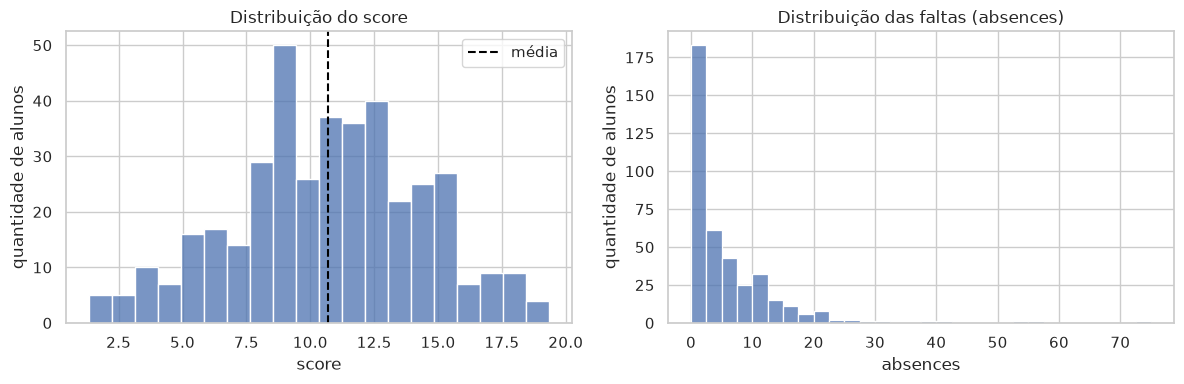

In [33]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(train["score"], bins=20, ax=ax[0])
ax[0].axvline(train["score"].mean(), color="black", linestyle="--", label="média")
ax[0].set_title("Distribuição do score")
ax[0].set_xlabel("score")
ax[0].set_ylabel("quantidade de alunos")
ax[0].legend()

sns.histplot(train["absences"], bins=30, ax=ax[1])
ax[1].set_title("Distribuição das faltas (absences)")
ax[1].set_xlabel("absences")
ax[1].set_ylabel("quantidade de alunos")

plt.tight_layout()
plt.show()

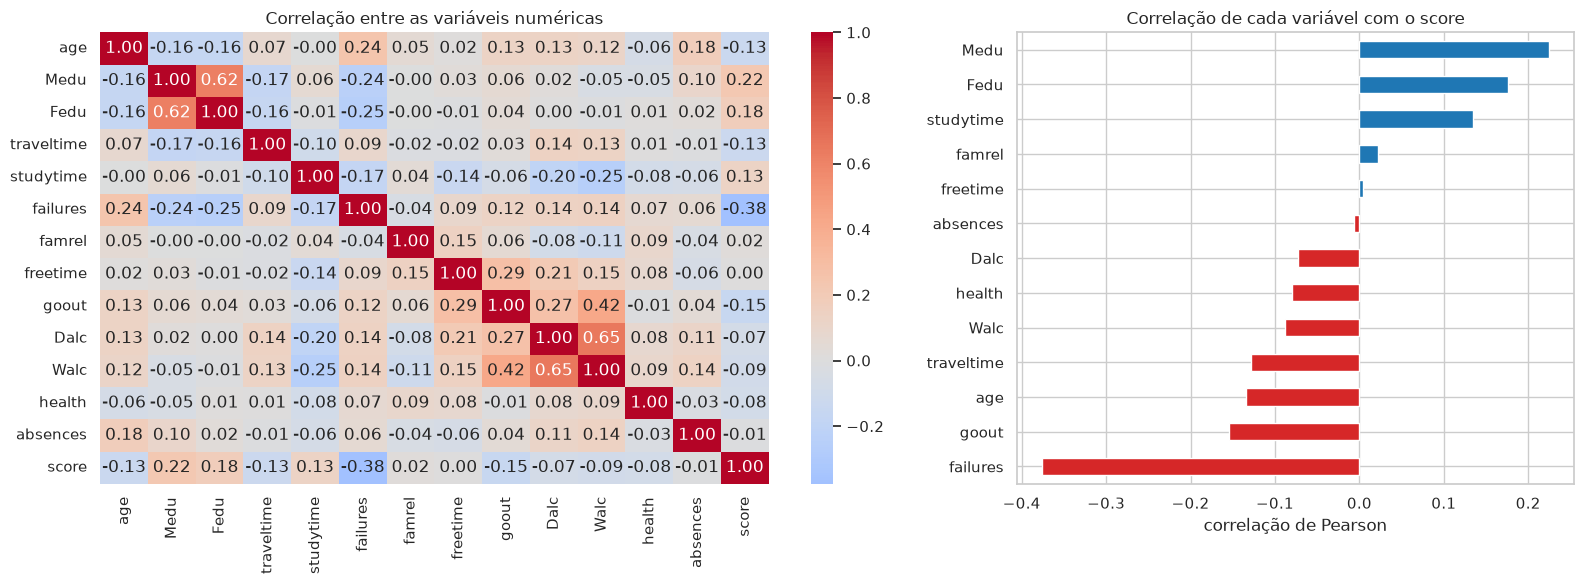

In [34]:
numericas = train.select_dtypes(include="number")

fig, ax = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [3, 2]})

sns.heatmap(numericas.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax[0])
ax[0].set_title("Correlação entre as variáveis numéricas")

corr_score = numericas.corr()["score"].drop("score").sort_values()
corr_score.plot.barh(ax=ax[1], color=np.where(corr_score > 0, "tab:blue", "tab:red"))
ax[1].set_title("Correlação de cada variável com o score")
ax[1].set_xlabel("correlação de Pearson")

plt.tight_layout()
plt.show()

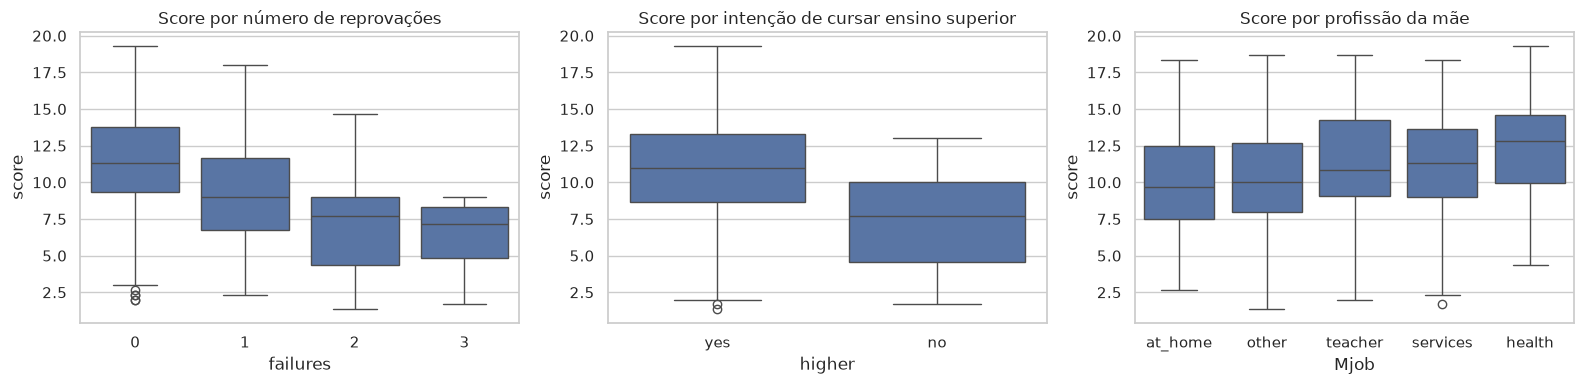

In [35]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

sns.boxplot(data=train, x="failures", y="score", ax=ax[0])
ax[0].set_title("Score por número de reprovações")

sns.boxplot(data=train, x="higher", y="score", ax=ax[1])
ax[1].set_title("Score por intenção de cursar ensino superior")

ordem_mjob = train.groupby("Mjob")["score"].median().sort_values().index
sns.boxplot(data=train, x="Mjob", y="score", order=ordem_mjob, ax=ax[2])
ax[2].set_title("Score por profissão da mãe")

plt.tight_layout()
plt.show()

In [36]:
for coluna in ["failures", "higher", "schoolsup", "Mjob"]:
    print(train.groupby(coluna)["score"].agg(["mean", "count"]).round(2))
    print()

           mean  count
failures              
0         11.36    312
1          8.98     50
2          7.31     17
3          6.35     16

         mean  count
higher              
no       7.65     20
yes     10.84    375

            mean  count
schoolsup              
no         10.87    344
yes         9.36     51

           mean  count
Mjob                  
at_home    9.76     59
health    12.23     34
other     10.06    141
services  11.21    103
teacher   11.27     58



## 1.2 Pré-processamento

In [37]:
X = pd.get_dummies(train.drop(columns=["score"]), drop_first=True)
y = train["score"]

X_test = pd.get_dummies(test, drop_first=True).reindex(columns=X.columns, fill_value=0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

print("Colunas após a codificação:", X.shape[1])

Colunas após a codificação: 39


## 1.3 Modelos

Todos os modelos são avaliados com a mesma validação cruzada de 5 partições.

In [38]:
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)


def rmse_cv(modelo):
    scores = -cross_val_score(modelo, X_scaled, y, cv=kf, scoring="neg_root_mean_squared_error")
    return scores.mean(), scores.std()


modelos_reg = {
    "Baseline (média)": DummyRegressor(strategy="mean"),
    "Regressão Linear": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(alpha=0.1),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR(),
    "Árvore de Decisão": DecisionTreeRegressor(random_state=SEED),
    "Random Forest": RandomForestRegressor(random_state=SEED),
    "Gradient Boosting": GradientBoostingRegressor(random_state=SEED),
    "XGBoost": XGBRegressor(random_state=SEED),
}

resultados_reg = []
for nome, modelo in modelos_reg.items():
    media, desvio = rmse_cv(modelo)
    resultados_reg.append({"modelo": nome, "RMSE médio": media, "desvio": desvio})

resultados_reg = pd.DataFrame(resultados_reg).sort_values("RMSE médio").reset_index(drop=True)
resultados_reg.round(4)

,modelo,RMSE médio,desvio
0,Random Forest,3.2362,0.1783
1,Gradient Boosting,3.3154,0.1143
2,Lasso,3.3795,0.1114
3,SVR,3.4013,0.1962
4,Ridge,3.4563,0.1089
5,Regressão Linear,3.4593,0.1110
6,XGBoost,3.5430,0.1796
7,Baseline (média),3.6886,0.2613
8,KNN,3.6973,0.2740
9,Árvore de Decisão,4.4792,0.3138


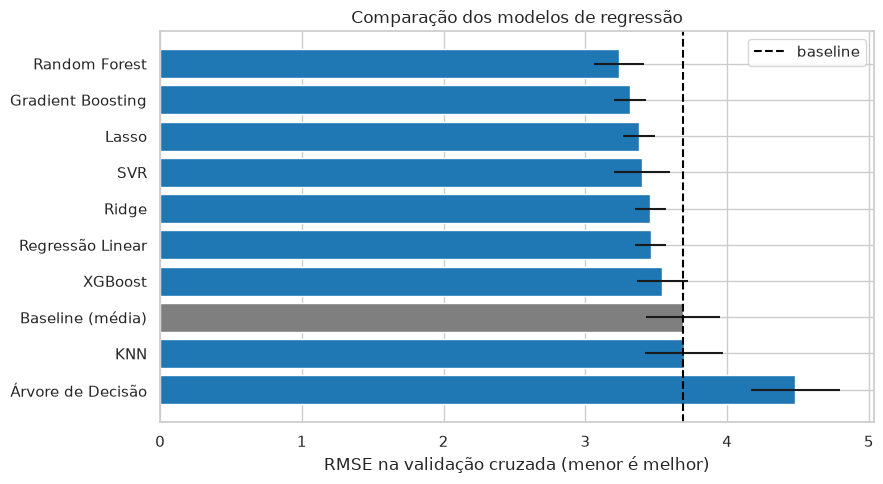

In [39]:
fig, ax = plt.subplots(figsize=(9, 5))
cores = ["tab:gray" if m.startswith("Baseline") else "tab:blue" for m in resultados_reg["modelo"]]
ax.barh(resultados_reg["modelo"], resultados_reg["RMSE médio"], xerr=resultados_reg["desvio"], color=cores)
ax.axvline(resultados_reg.loc[resultados_reg["modelo"] == "Baseline (média)", "RMSE médio"].item(),
           color="black", linestyle="--", label="baseline")
ax.invert_yaxis()
ax.set_xlabel("RMSE na validação cruzada (menor é melhor)")
ax.set_title("Comparação dos modelos de regressão")
ax.legend()
plt.tight_layout()
plt.show()

### Ajuste de hiperparâmetros

In [40]:
grids = {
    "Random Forest": (
        RandomForestRegressor(random_state=SEED),
        {
            "n_estimators": [100, 200, 300],
            "max_depth": [None, 5, 10, 15],
            "min_samples_leaf": [1, 2, 4],
            "max_features": ["sqrt", 0.5, 1.0],
        },
    ),
    "Gradient Boosting": (
        GradientBoostingRegressor(random_state=SEED),
        {
            "n_estimators": [100, 200, 300],
            "max_depth": [2, 3, 4],
            "learning_rate": [0.01, 0.05, 0.1],
            "min_samples_leaf": [1, 2, 4],
        },
    ),
    "XGBoost": (
        XGBRegressor(random_state=SEED),
        {
            "n_estimators": [100, 200, 300],
            "max_depth": [2, 3, 4],
            "learning_rate": [0.01, 0.05, 0.1],
            "min_child_weight": [1, 3, 5],
        },
    ),
}

melhores_params = {}
melhores_rmse = {}
for nome, (modelo, grid) in grids.items():
    busca = GridSearchCV(modelo, grid, cv=kf, scoring="neg_root_mean_squared_error", n_jobs=-1)
    busca.fit(X_scaled, y)
    melhores_params[nome] = busca.best_params_
    melhores_rmse[nome] = -busca.best_score_
    print(f"{nome}: RMSE = {-busca.best_score_:.4f}")
    print(f"  parâmetros: {busca.best_params_}")

Random Forest: RMSE = 3.2133
  parâmetros: {'max_depth': 15, 'max_features': 1.0, 'min_samples_leaf': 2, 'n_estimators': 300}
Gradient Boosting: RMSE = 3.1950
  parâmetros: {'learning_rate': 0.05, 'max_depth': 2, 'min_samples_leaf': 4, 'n_estimators': 200}
XGBoost: RMSE = 3.1999
  parâmetros: {'learning_rate': 0.05, 'max_depth': 2, 'min_child_weight': 5, 'n_estimators': 200}


### Ensemble dos modelos ajustados

Os três modelos erram de formas diferentes, então a média das previsões tende a ser mais estável do que qualquer um deles sozinho. Testei duas combinações, sempre com as mesmas partições: a média de Random Forest e Gradient Boosting, e a média dos três.

In [41]:
def criar_modelo(nome):
    modelos = {
        "Random Forest": RandomForestRegressor(random_state=SEED),
        "Gradient Boosting": GradientBoostingRegressor(random_state=SEED),
        "XGBoost": XGBRegressor(random_state=SEED),
    }
    return modelos[nome].set_params(**melhores_params[nome])


def rmse_ensemble(nomes):
    rmses = []
    for idx_treino, idx_val in kf.split(X_scaled):
        previsoes = []
        for nome in nomes:
            modelo = criar_modelo(nome)
            modelo.fit(X_scaled[idx_treino], y.iloc[idx_treino])
            previsoes.append(modelo.predict(X_scaled[idx_val]))
        media_previsoes = np.mean(previsoes, axis=0)
        rmses.append(np.sqrt(mean_squared_error(y.iloc[idx_val], media_previsoes)))
    return np.mean(rmses), np.std(rmses)


combinacoes = {
    "RF + GB": ["Random Forest", "Gradient Boosting"],
    "RF + GB + XGB": ["Random Forest", "Gradient Boosting", "XGBoost"],
}

rmse_ensembles = {}
for rotulo, nomes in combinacoes.items():
    media, desvio = rmse_ensemble(nomes)
    rmse_ensembles[rotulo] = media
    print(f"{rotulo}: RMSE = {media:.4f} (desvio {desvio:.4f})")

RF + GB: RMSE = 3.1754 (desvio 0.1673)
RF + GB + XGB: RMSE = 3.1765 (desvio 0.1637)


As duas combinações superam todos os modelos individuais, mas por pouco: 3,175 contra 3,195 do melhor modelo sozinho. Escolhi a média dos três modelos para a submissão.

## 1.4 Avaliação

A tabela abaixo resume a evolução do RMSE ao longo das etapas, sempre medido na mesma validação cruzada.

In [42]:
resumo_reg = pd.DataFrame({
    "etapa": [
        "Baseline (média)",
        "Melhor modelo linear (Lasso)",
        "Melhor modelo com parâmetros padrão (Random Forest)",
        "Melhor modelo ajustado individualmente",
        "Ensemble final (RF + GB + XGB)",
    ],
    "RMSE": [
        resultados_reg.loc[resultados_reg["modelo"] == "Baseline (média)", "RMSE médio"].item(),
        resultados_reg.loc[resultados_reg["modelo"] == "Lasso", "RMSE médio"].item(),
        resultados_reg.loc[resultados_reg["modelo"] == "Random Forest", "RMSE médio"].item(),
        min(melhores_rmse.values()),
        rmse_ensembles["RF + GB + XGB"],
    ],
})
resumo_reg["redução em relação ao baseline"] = 1 - resumo_reg["RMSE"] / resumo_reg["RMSE"].iloc[0]
resumo_reg.round(4)

,etapa,RMSE,redução em relação ao baseline
0,Baseline (média),3.6886,0.0000
1,Melhor modelo linear (Lasso),3.3795,0.0838
2,Melhor modelo com parâmetros padrão (Random Fo...,3.2362,0.1226
3,Melhor modelo ajustado individualmente,3.1950,0.1338
4,Ensemble final (RF + GB + XGB),3.1765,0.1388


# Parte 2: Classificação (Breast Cancer Wisconsin)


## 2.1 Análise exploratória

In [43]:
train2 = pd.read_csv("classiicacao/train2.csv")
test2 = pd.read_csv("classiicacao/test2.csv")

print("Treino:", train2.shape)
print("Teste:", test2.shape)
print("Valores ausentes no treino:", train2.isnull().sum().sum())
print("Valores ausentes no teste:", test2.isnull().sum().sum())
train2.head()

Treino: (569, 31)
Teste: (40, 30)
Valores ausentes no treino: 0
Valores ausentes no teste: 0


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


           quantidade  proporção
diagnosis                       
B                 357     0.6274
M                 212     0.3726


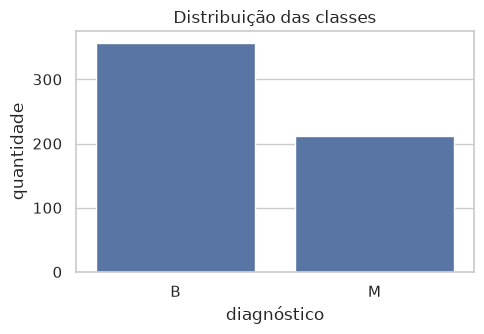

In [44]:
contagem = train2["diagnosis"].value_counts()
proporcao = train2["diagnosis"].value_counts(normalize=True)
print(pd.DataFrame({"quantidade": contagem, "proporção": proporcao.round(4)}))

fig, ax = plt.subplots(figsize=(5, 3.5))
sns.countplot(data=train2, x="diagnosis", order=["B", "M"], ax=ax)
ax.set_title("Distribuição das classes")
ax.set_xlabel("diagnóstico")
ax.set_ylabel("quantidade")
plt.tight_layout()
plt.show()

In [45]:
destaque = ["radius_mean", "concave points_mean", "texture_mean", "smoothness_mean"]
train2.groupby("diagnosis")[destaque].mean().round(4)

,radius_mean,concave points_mean,texture_mean,smoothness_mean
diagnosis,,,,
B,12.1465,0.0257,17.9148,0.0925
M,17.4628,0.0880,21.6049,0.1029


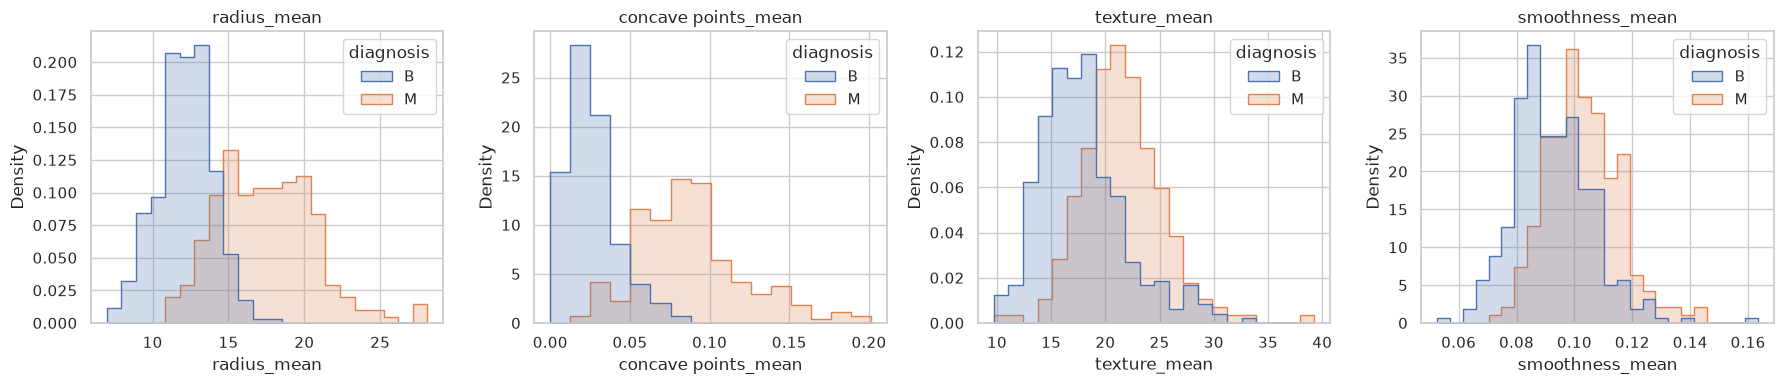

In [46]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, coluna in zip(axes, destaque):
    sns.histplot(data=train2, x=coluna, hue="diagnosis", hue_order=["B", "M"],
                 element="step", stat="density", common_norm=False, ax=ax)
    ax.set_title(coluna)
plt.tight_layout()
plt.show()

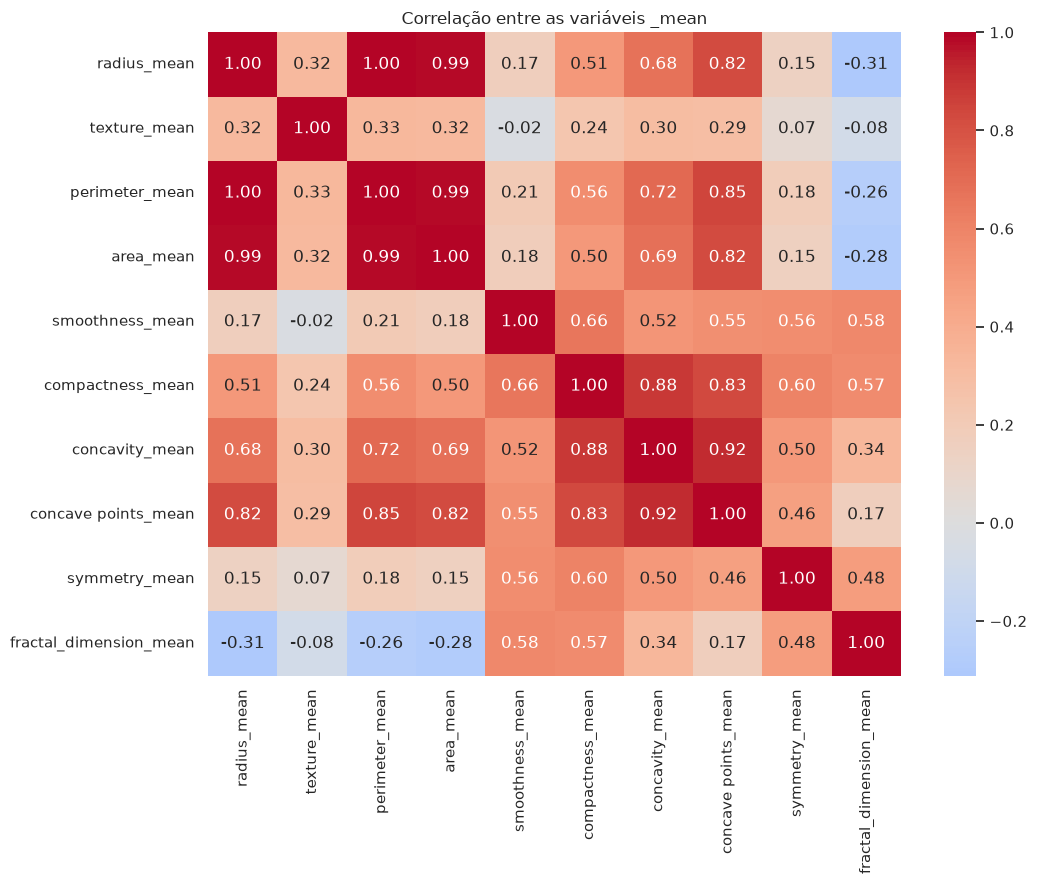

In [47]:
colunas_mean = [c for c in train2.columns if c.endswith("_mean")]

plt.figure(figsize=(11, 9))
sns.heatmap(train2[colunas_mean].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlação entre as variáveis _mean")
plt.tight_layout()
plt.show()

## 2.2 Pré-processamento


In [48]:
X2 = train2.drop(columns=["diagnosis"])
y2 = train2["diagnosis"].map({"M": 1, "B": 0})

scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)
X2_test_scaled = scaler2.transform(test2[X2.columns])

y2.value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

## 2.3 Modelos

In [49]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

modelos_clf = {
    "Baseline (classe majoritária)": DummyClassifier(strategy="most_frequent"),
    "Regressão Logística": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "SVM (linear)": SVC(kernel="linear"),
    "SVM (RBF)": SVC(kernel="rbf"),
    "Árvore de Decisão": DecisionTreeClassifier(random_state=SEED),
    "Random Forest": RandomForestClassifier(random_state=SEED),
    "Gradient Boosting": GradientBoostingClassifier(random_state=SEED),
    "XGBoost": XGBClassifier(random_state=SEED),
}

resultados_clf = []
for nome, modelo in modelos_clf.items():
    scores = cross_val_score(modelo, X2_scaled, y2, cv=skf, scoring="accuracy")
    resultados_clf.append({"modelo": nome, "acurácia média": scores.mean(), "desvio": scores.std()})

resultados_clf = pd.DataFrame(resultados_clf).sort_values("acurácia média", ascending=False).reset_index(drop=True)
resultados_clf.round(4)

,modelo,acurácia média,desvio
0,SVM (linear),0.9754,0.0195
1,SVM (RBF),0.9754,0.0195
2,Regressão Logística,0.9737,0.0166
3,KNN,0.9666,0.0140
4,XGBoost,0.9631,0.0102
5,Random Forest,0.9543,0.0128
6,Gradient Boosting,0.9508,0.0245
7,Naive Bayes,0.9297,0.0199
8,Árvore de Decisão,0.9104,0.0279
9,Baseline (classe majoritária),0.6274,0.0039


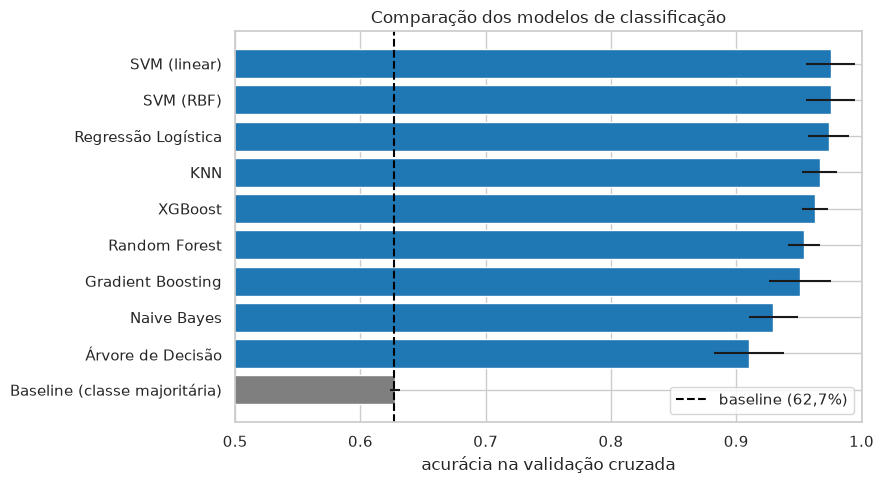

In [50]:
fig, ax = plt.subplots(figsize=(9, 5))
cores = ["tab:gray" if m.startswith("Baseline") else "tab:blue" for m in resultados_clf["modelo"]]
ax.barh(resultados_clf["modelo"], resultados_clf["acurácia média"], xerr=resultados_clf["desvio"], color=cores)
ax.axvline(0.627, color="black", linestyle="--", label="baseline (62,7%)")
ax.set_xlim(0.5, 1.0)
ax.invert_yaxis()
ax.set_xlabel("acurácia na validação cruzada")
ax.set_title("Comparação dos modelos de classificação")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Ajuste de hiperparâmetros

In [51]:
busca_lr = GridSearchCV(
    LogisticRegression(max_iter=5000),
    {"C": [0.01, 0.1, 0.5, 1, 10, 100], "class_weight": [None, "balanced"]},
    cv=skf,
    scoring="accuracy",
)
busca_lr.fit(X2_scaled, y2)

busca_svm = GridSearchCV(
    SVC(),
    {"kernel": ["linear", "rbf"], "C": [0.01, 0.1, 1, 10, 100], "class_weight": [None, "balanced"]},
    cv=skf,
    scoring="accuracy",
)
busca_svm.fit(X2_scaled, y2)

print(f"Regressão Logística: acurácia = {busca_lr.best_score_:.4f}")
print(f"  parâmetros: {busca_lr.best_params_}")
print(f"SVM: acurácia = {busca_svm.best_score_:.4f}")
print(f"  parâmetros: {busca_svm.best_params_}")

Regressão Logística: acurácia = 0.9754
  parâmetros: {'C': 0.1, 'class_weight': 'balanced'}
SVM: acurácia = 0.9807
  parâmetros: {'C': 10, 'class_weight': 'balanced', 'kernel': 'rbf'}


## 2.4 Avaliação


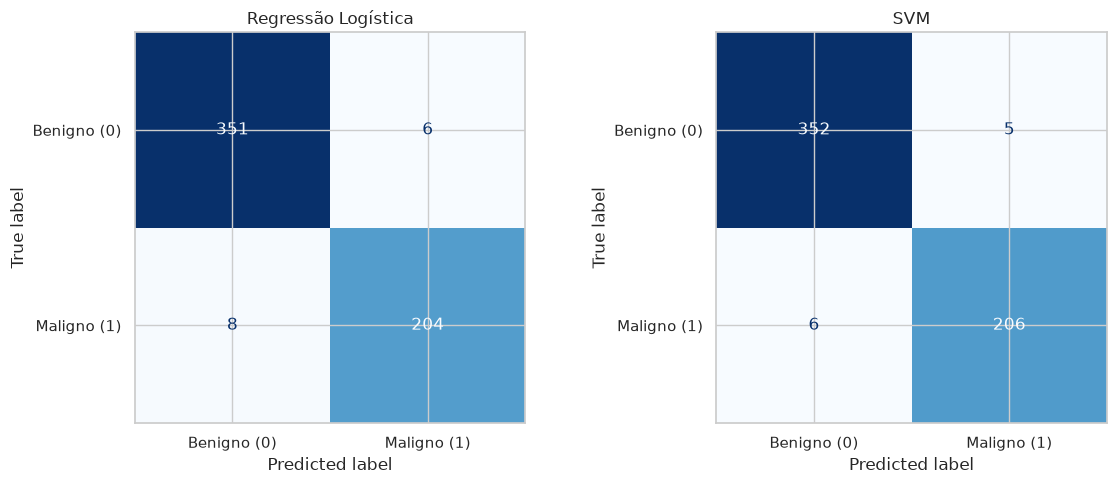

Regressão Logística
  Verdadeiros positivos (malignos detectados): 204
  Verdadeiros negativos (benignos corretos):   351
  Falsos positivos (benignos marcados como malignos): 6
  Falsos negativos (malignos não detectados):  8
  Acurácia: 0.9754
  Sensibilidade (malignos detectados / total de malignos): 0.9623

SVM
  Verdadeiros positivos (malignos detectados): 206
  Verdadeiros negativos (benignos corretos):   352
  Falsos positivos (benignos marcados como malignos): 5
  Falsos negativos (malignos não detectados):  6
  Acurácia: 0.9807
  Sensibilidade (malignos detectados / total de malignos): 0.9717



In [52]:
modelo_lr = LogisticRegression(max_iter=5000, **busca_lr.best_params_)
modelo_svm = SVC(**busca_svm.best_params_)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
matrizes = {}
for ax, (nome, modelo) in zip(axes, [("Regressão Logística", modelo_lr), ("SVM", modelo_svm)]):
    y2_pred = cross_val_predict(modelo, X2_scaled, y2, cv=skf)
    cm = confusion_matrix(y2, y2_pred)
    matrizes[nome] = cm
    ConfusionMatrixDisplay(cm, display_labels=["Benigno (0)", "Maligno (1)"]).plot(cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(nome)
plt.tight_layout()
plt.show()

for nome, cm in matrizes.items():
    vn, fp, fn, vp = cm.ravel()
    print(nome)
    print(f"  Verdadeiros positivos (malignos detectados): {vp}")
    print(f"  Verdadeiros negativos (benignos corretos):   {vn}")
    print(f"  Falsos positivos (benignos marcados como malignos): {fp}")
    print(f"  Falsos negativos (malignos não detectados):  {fn}")
    print(f"  Acurácia: {(vp + vn) / cm.sum():.4f}")
    print(f"  Sensibilidade (malignos detectados / total de malignos): {vp / (vp + fn):.4f}")
    print()

O modelo escolhido para a submissão foi o SVM.

In [53]:
C_escolhido = busca_lr.best_params_["C"]
lr_sem_peso = LogisticRegression(max_iter=5000, C=C_escolhido)
y2_pred_sem_peso = cross_val_predict(lr_sem_peso, X2_scaled, y2, cv=skf)
vn, fp, fn, vp = confusion_matrix(y2, y2_pred_sem_peso).ravel()

print(f"Regressão Logística com C={C_escolhido} e sem class_weight")
print(f"  Acurácia: {(vp + vn) / len(y2):.4f}")
print(f"  Falsos negativos: {fn}")
print(f"  Falsos positivos: {fp}")

Regressão Logística com C=0.1 e sem class_weight
  Acurácia: 0.9736
  Falsos negativos: 13
  Falsos positivos: 2


# Parte 3: Submissão no Kaggle

In [54]:
previsoes_reg = []
for nome in combinacoes["RF + GB + XGB"]:
    modelo = criar_modelo(nome)
    modelo.fit(X_scaled, y)
    previsoes_reg.append(modelo.predict(X_test_scaled))

previsoes_reg = np.clip(np.mean(previsoes_reg, axis=0), 0, 20)

submission = pd.DataFrame({"ID": range(len(previsoes_reg)), "Score": previsoes_reg})
submission.to_csv("regressao/submission.csv", index=False)
submission.head()

,ID,Score
0,0,12.934351
1,1,11.882148
2,2,6.727621
3,3,11.356597
4,4,12.608883


In [55]:
modelo_final_clf = SVC(**busca_svm.best_params_)
modelo_final_clf.fit(X2_scaled, y2)
previsoes_clf = modelo_final_clf.predict(X2_test_scaled)

submission2 = pd.DataFrame({"id": range(len(previsoes_clf)), "diagnosis": previsoes_clf})
submission2.to_csv("classiicacao/submission.csv", index=False)
submission2.head()

,id,diagnosis
0,0,0
1,1,0
2,2,0
3,3,1
4,4,0


### Conferência dos arquivos


In [56]:
sub_reg = pd.read_csv("regressao/submission.csv")
sub_clf = pd.read_csv("classiicacao/submission.csv")

print("Regressão")
print("  linhas:", len(sub_reg), "| linhas do teste:", len(test), "| ok:", len(sub_reg) == len(test))
print("  valores faltantes:", sub_reg.isnull().sum().sum())
print(f"  faixa das notas: {sub_reg['Score'].min():.2f} a {sub_reg['Score'].max():.2f}")
print()
print("Classificação")
print("  linhas:", len(sub_clf), "| linhas do teste:", len(test2), "| ok:", len(sub_clf) == len(test2))
print("  valores faltantes:", sub_clf.isnull().sum().sum())
print("  valores distintos:", sorted(sub_clf["diagnosis"].unique().tolist()))
print("  contagem:", sub_clf["diagnosis"].value_counts().to_dict())

Regressão
  linhas: 40 | linhas do teste: 40 | ok: True
  valores faltantes: 0
  faixa das notas: 4.64 a 12.93

Classificação
  linhas: 40 | linhas do teste: 40 | ok: True
  valores faltantes: 0
  valores distintos: [0, 1]
  contagem: {0: 27, 1: 13}


Os dois arquivos têm o mesmo número de linhas dos respectivos testes, nenhum valor faltante e valores dentro do esperado. As notas previstas ficam concentradas perto da média, o que é natural para um modelo com erro de cerca de 3 pontos. As classes previstas usam apenas 0 e 1, no formato aceito pela competição.

# Conclusão

Na regressão, o melhor resultado foi a média de Random Forest, Gradient Boosting e XGBoost ajustados, com RMSE de cerca de 3,18 na validação cruzada, contra 3,69 do baseline que prevê sempre a média. O ganho é limitado pela própria natureza dos dados. A nota de um aluno depende de muitos fatores fracos, e só o histórico de reprovações tem uma relação forte com ela.

Na classificação, o problema é bem mais fácil. Quase todos os modelos passaram de 95% de acurácia, contra 62,7% do baseline. O modelo escolhido foi um SVM com kernel RBF e pesos balanceados entre as classes, com acurácia de 98,1% e 6 falsos negativos em 212 casos malignos. A escolha levou em conta não só a acurácia, mas principalmente o número de tumores malignos não detectados.

Nas duas partes, a comparação com um baseline simples e o uso das mesmas partições de validação para todos os modelos foram o que permitiu avaliar os resultados com critério. Sem essas referências, um RMSE de 3,2 ou uma acurácia de 97% seriam números difíceis de interpretar.